# NWS warnings and watches by county

Every National Weather Service watch, warning, and advisory carries a VTEC
code: a phenomenon (`TO` tornado, `SV` severe thunderstorm), a significance
(`W` warning, `A` watch, `Y` advisory), an issuing office, and an event
number. The Iowa Environmental Mesonet (IEM) at Iowa State University
archives the NWS product stream and serves those events per county or
forecast zone; the NWS's own API keeps no archive. One request returns one
CSV with a row per event issued for that county: when it was issued, when it
expired, what it was, and which product carried it.

This walkthrough pulls every event issued for Osage County, Oklahoma in 2024
and looks at how long each kind lasts. It needs `usdata[pandas]` and
matplotlib; the file is about 40 KB and the run takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:06:34+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one county and a year. `Osage County, OK` becomes the NWS
code `OKC113`: the state's postal code, `C` for county, and the county FIPS
code. A bounding box or a whole state is refused, because the service answers
for one code at a time. The window selects events by when they were
**issued**, from the first instant of 2024 to the last; it cannot select what
was in effect at a moment. A county code reaches county-based products only
(tornado, severe thunderstorm, flood); heat, fire, and winter products are
issued by forecast zone and need `params: {ugc: ...}` instead.

In [2]:
print(manifest.read_text())

name: osage-county-warnings-2024
sources:
  - name: events
    dataset: noaa:nws-vtec-events
    # A county reaches county-based products: tornado, severe thunderstorm, flood.
    location: Osage County, OK
    start: 2024-01-01
    end: 2024-12-31



## What arrives

One CSV. The service offers no count, so the pull fetches whatever the window
holds; a quiet window arrives as a header with no rows rather than an error.
The first pull writes `dataset.lock.json` beside the manifest with the file's
checksum.

In [3]:
result = pull(manifest)
item = result.one("events")
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: vtec_OKC113_20240101_20241231_d5a06c94bcd90272db9c.csv
Bytes: 37677
Source: https://mesonet.agron.iastate.edu/json/vtec_events_byugc.py?ugc=OKC113&sts=2024-01-01T00%3A00%3A00Z&ets=2025-01-01T00%3A00%3A00Z&fmt=csv
Retrieved (UTC): 2026-09-24T06:06:37+00:00
Checksum: sha256:999cb754e8a673f343c3f51910cf4025e7f7a69a459a3d59ac5d9df37fbc6143


## Open

The generic CSV reader returns a DataFrame. `iso_issued` and `iso_expired`
are UTC instants; `parse_dates` makes them timezone-aware. (`issued` and
`expired` hold the same instants as text with no timezone.) `phenomena` and
`significance` are the VTEC codes and `name` spells them out. `eventid` is
numbered per office, phenomenon, significance, and year, so the same number
recurs across types. Place is only the `ugc` asked for: rows carry no
coordinates or polygons.

In [4]:
events = item.open_csv(parse_dates=["iso_issued", "iso_expired"])
events["minutes"] = (events["iso_expired"] - events["iso_issued"]).dt.total_seconds() / 60
print(f"{len(events)} events for {', '.join(events['ugc'].unique())}")
print("Issuing offices:", ", ".join(events["wfo"].unique()))
print("Issued by month:", events.groupby(events["iso_issued"].dt.month).size().to_dict())
columns = ["phenomena", "significance", "eventid", "name", "iso_issued", "iso_expired"]
events[columns].head()

151 events for OKC113
Issuing offices: TSA
Issued by month: {3: 3, 4: 44, 5: 53, 6: 16, 7: 4, 8: 10, 9: 5, 10: 6, 11: 10}


,phenomena,significance,eventid,name,iso_issued,iso_expired
0,SV,A,30,Severe Thunderstorm Watch,2024-03-07 20:27:00+00:00,2024-03-08 03:00:00+00:00
1,SV,W,8,Severe Thunderstorm Warning,2024-03-08 02:18:00+00:00,2024-03-08 03:15:00+00:00
2,SV,W,9,Severe Thunderstorm Warning,2024-03-14 01:22:00+00:00,2024-03-14 02:00:00+00:00
3,TO,A,65,Tornado Watch,2024-04-01 19:15:00+00:00,2024-04-02 04:35:00+00:00
4,SV,W,54,Severe Thunderstorm Warning,2024-04-01 19:27:00+00:00,2024-04-01 20:15:00+00:00


To ask what was in effect at a moment, compare the two instants yourself. The
year-long window already reaches back far enough for any moment inside it
except the first hours of January.

In [5]:
moment = pd.Timestamp("2024-05-07T02:12Z")
in_effect = events[(events["iso_issued"] <= moment) & (events["iso_expired"] > moment)]
print(f"In effect at {moment:%Y-%m-%d %H:%M} UTC, the start of that evening's EF4:")
in_effect[["name", "eventid", "iso_issued", "iso_expired"]]

In effect at 2024-05-07 02:12 UTC, the start of that evening's EF4:


,name,eventid,iso_issued,iso_expired
59,Tornado Watch,189,2024-05-06 19:05:00+00:00,2024-05-07 03:48:00+00:00
60,Severe Thunderstorm Warning,175,2024-05-07 01:21:00+00:00,2024-05-07 02:15:00+00:00
61,Severe Thunderstorm Warning,176,2024-05-07 01:31:00+00:00,2024-05-07 02:15:00+00:00
63,Severe Thunderstorm Warning,177,2024-05-07 01:49:00+00:00,2024-05-07 02:30:00+00:00
64,Tornado Warning,45,2024-05-07 01:56:00+00:00,2024-05-07 02:45:00+00:00
65,Severe Thunderstorm Warning,178,2024-05-07 02:03:00+00:00,2024-05-07 02:45:00+00:00


## A first look

How long each kind of event lasted, from issuance to expiry, one dot per
event on a logarithmic axis, with the median marked. `iso_expired` is when
the event ended for this county, so a warning cancelled early counts as
short.

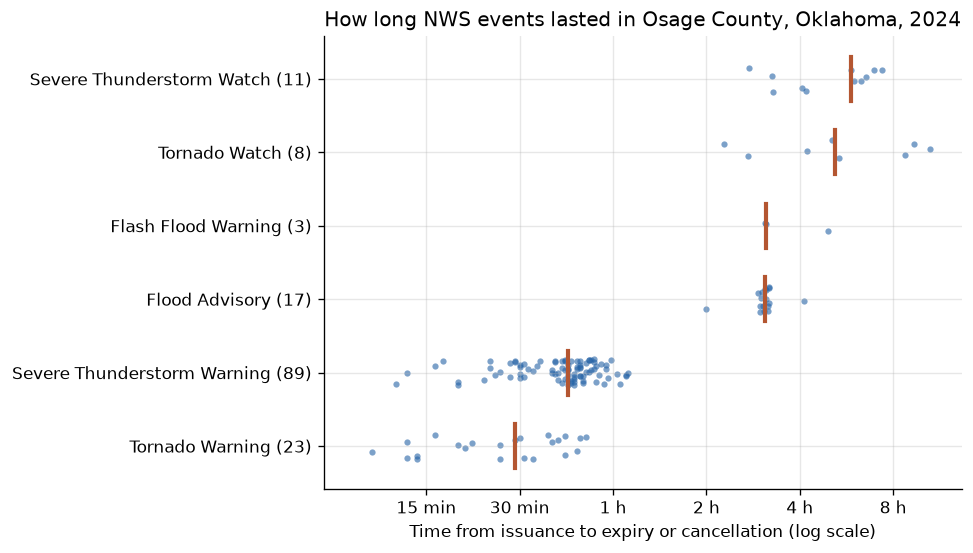

In [6]:
order = events.groupby("name")["minutes"].median().sort_values().index
rng = np.random.default_rng(0)
fig, ax = plt.subplots(layout="constrained")
for row, name in enumerate(order):
    minutes = events.loc[events["name"] == name, "minutes"]
    jitter = rng.uniform(-0.18, 0.18, len(minutes))
    ax.scatter(minutes, row + jitter, s=14, alpha=0.6, color="#2563a6", linewidths=0)
    ax.plot([minutes.median()] * 2, [row - 0.3, row + 0.3], color="#b45631", linewidth=2.5)
labels = [f"{name} ({(events['name'] == name).sum()})" for name in order]
ax.set_yticks(range(len(order)), labels)
ax.set_xscale("log")
ticks = [15, 30, 60, 120, 240, 480]
ax.set_xticks(ticks, ["15 min", "30 min", "1 h", "2 h", "4 h", "8 h"])
ax.set_xlim(7, 800)
ax.minorticks_off()
ax.set_xlabel("Time from issuance to expiry or cancellation (log scale)")
ax.set_title("How long NWS events lasted in Osage County, Oklahoma, 2024")
plt.show()

In [7]:
summary = events.groupby("name")["minutes"].agg(["count", "median", "max"]).round(0)
summary.loc[order]

,count,median,max
name,,,
Tornado Warning,23,29.0,49.0
Severe Thunderstorm Warning,89,43.0,67.0
Flood Advisory,17,185.0,248.0
Flash Flood Warning,3,187.0,296.0
Tornado Watch,8,312.0,633.0
Severe Thunderstorm Watch,11,351.0,442.0


Tornado warnings lasted a median of 29 minutes and severe thunderstorm
warnings 43; watches ran for hours, the longest Tornado Watch over ten. That
spread is what a question about "in effect"
depends on: a window that starts a few minutes before a moment catches the
warnings still running but misses a watch issued in the afternoon. Severe
thunderstorm warnings outnumber tornado warnings four to one here, and April
and May hold most of both.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nws-vtec-events
  National Weather Service watch, warning, and advisory products, as archived and served by the Iowa Environmental Mesonet of Iowa State University, accessed via usdata
  homepage: https://mesonet.agron.iastate.edu/info/datasets/vtec.html
  license: Public domain (NWS products; IEM materials are public domain, attribution appreciated)
  terms: https://mesonet.agron.iastate.edu/disclaimer.php
  retrieved: 2026-09-24; 1 checksummed asset (37,677 bytes) pinned by usdata 0.26.0
  sources: events


## What was awkward

- The obvious question, "what was in effect at this moment?", is not one the
  service can be asked. The window selects by issuance, so it has to reach
  back far enough to catch everything still running, and how far depends on
  the product: minutes for a warning, most of a day for a watch.
- A county code misses every zone-based product. Osage County's heat, fire
  weather, and winter products were issued for forecast zone `OKZ054` in 2024,
  and that zone was split in three in 2026, so the right code depends on the
  date asked about.
- `issued` and `expired` look interchangeable with `iso_issued` and
  `iso_expired` but carry no timezone; only the ISO pair parses as UTC.
- `eventid` reads as an integer, which drops the leading zeros the IEM `url`
  column shows (`eventid=0030`), and it is unique only together with the
  office, phenomenon, significance, and year.
- A county is listed on a warning when the warning's polygon touches it, so
  these rows say a warning named the county, not that it covered a given
  place. Osage is Oklahoma's largest county. The
  [warning lead time study](https://usdata.dev/studies/warning-lead-time/)
  runs into this, and the
  [warnings guide](https://docs.usdata.dev/providers/noaa-nws-vtec-events/)
  covers the service's other surprises.